Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


Detected Classes: ['Bleached', 'Unbleached']


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


Epoch [1/5] Loss: 0.3681, Val Acc: 94.20%
Epoch [2/5] Loss: 0.1219, Val Acc: 97.10%
Epoch [3/5] Loss: 0.0812, Val Acc: 97.10%
Epoch [4/5] Loss: 0.0453, Val Acc: 95.65%
Epoch [5/5] Loss: 0.0910, Val Acc: 97.10%


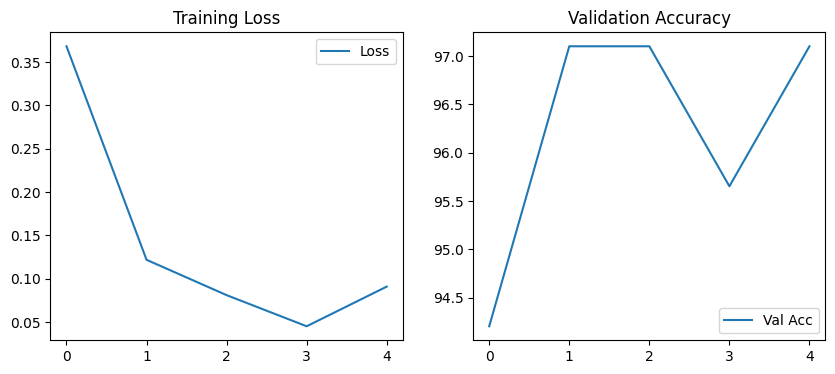

✅ Lightweight model saved as coral_bleaching_lightweight.pt


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# ================================
# Setup
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ✅ Path to dataset
DATA_DIR = "/kaggle/input/bleached-corals-detection/Train"

# ================================
# Transformations
# ================================
transform = transforms.Compose([
    transforms.Resize((160, 160)),  # Smaller size for CPU
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                         [0.229, 0.224, 0.225])  # ImageNet std
])

# ================================
# Dataset & DataLoaders
# ================================
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
print("Detected Classes:", dataset.classes)

# Manual label map (optional)
LABEL_MAP = {0: "Bleached", 1: "Not Bleached"}

# Train-validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, num_workers=0)

# ================================
# Model (MobileNetV2)
# ================================
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)  # 2 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ================================
# Training
# ================================
epochs = 5
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_losses.append(running_loss / len(train_loader))

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {train_losses[-1]:.4f}, Val Acc: {val_acc:.2f}%")

# ================================
# Plots
# ================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Loss")
plt.plot(train_losses, label="Loss")
plt.legend()
plt.subplot(1,2,2)
plt.title("Validation Accuracy")
plt.plot(val_accuracies, label="Val Acc")
plt.legend()
plt.show()

# ================================
# Save Model
# ================================
torch.save(model.state_dict(), "coral_bleaching_lightweight.pt")
print("✅ Lightweight model saved as coral_bleaching_lightweight.pt")
